# Tests of the sliding diffusion concept

The following with be experiements and tests of hyperparameter configurations, sometimes with numerical evalusaions, and prints for analasis. 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from local_attention import transformer
from local_attention.rotary import SinusoidalEmbeddings, apply_rotary_pos_emb
import matplotlib.pyplot as plt
from typing import Union
from io import BytesIO
from PIL import Image
from moviepy import ImageSequenceClip
from datetime import datetime
from v1_sliding_diffusion import Diffusion

device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu")

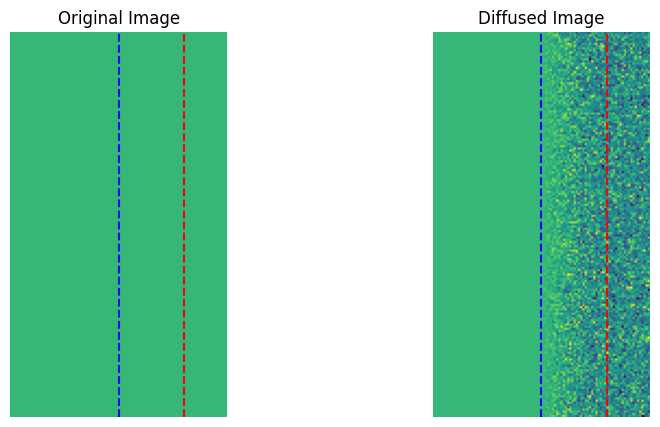

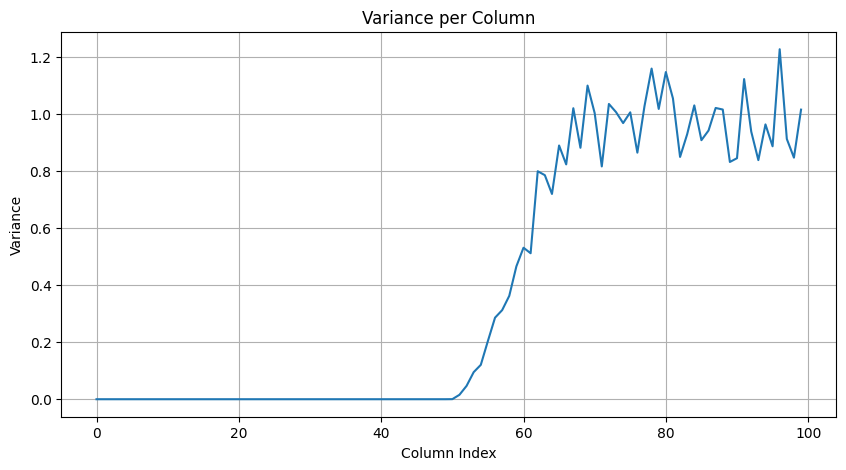

In [ ]:
# Initialize the diffusion class
diffusion = Diffusion(
        num_of_pre_timestep_frames = 50, 
        num_of_timestep_frames = 30, 
        num_of_post_timestep_frames = 20, 
        noise_schedule = Diffusion.linear_schedule(0.0002, 0.40),
        device = device
    )

# Create a tensor that is all white so we can see the noising process removing details
image = torch.ones((177, 100))
image = image.to(device)

# Run the forward diffusion function
transformed_image = diffusion.forward(seqence_tensor = image)

# Draw both images next to each other in the python notebook
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image.cpu().numpy(), vmin=-3, vmax=3)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_image.cpu().numpy(), vmin=-3, vmax=3)
ax[1].set_title("Diffused Image")
ax[1].axis("off")

# Draw a vertical line at num_of_pre_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

# Draw a vertical line at num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames + diffusion.num_of_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='red', linestyle='--', label='Timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

plt.show()

# Calculate the variance per frame (vertical slice)
variances = torch.var(transformed_image, dim=0)

# Plot the variance for each column
plt.figure(figsize=(10, 5))
plt.plot(variances.cpu().numpy())
plt.title("Variance per Column")
plt.xlabel("Column Index")
plt.ylabel("Variance")
plt.grid(True)

# Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
plt.axvline(x=line_x + diffusion.num_of_timestep_frames, color='red', linestyle='--', label='Timestep frames')


plt.show()

In [4]:
from v1_model import ContinuousMotionModel
from debugger import Debugger
from v1_traing_loop import train
from v1_sliding_diffusion import Diffusion

### Experiment 01

In [ ]:
model = ContinuousMotionModel(
        deffsion_noise_scheduler=Diffusion(
                num_of_pre_timestep_frames=50,
                num_of_timestep_frames=100,
                num_of_post_timestep_frames=0,
                noise_schedule=Diffusion.linear_schedule(0.0002, 0.005)),
        number_of_styles = 17,
        n_gesture_length = 150,
        n_seed_length = 8,
        audio_features_per_frame = 804,
        pose_features_per_frame = 177,
        number_of_attention_heads = 8,
        debugger = Debugger(
            False, 
            ["ALL"]
        )
)

SyntaxError: invalid syntax (811207907.py, line 2)